## Q4 — What is the longest match recorded in terms of duration?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load
IN_DIR = "cleaned_data"

event = pd.read_parquet(f'{IN_DIR}/event.parquet')
time_df = pd.read_parquet(f'{IN_DIR}/time.parquet')
home = pd.read_parquet(f'{IN_DIR}/home_team.parquet')
away = pd.read_parquet(f'{IN_DIR}/away_team.parquet')
tourn = pd.read_parquet(f'{IN_DIR}/tournament.parquet')
hts = pd.read_parquet(f'{IN_DIR}/home_team_score.parquet')
ats = pd.read_parquet(f'{IN_DIR}/away_team_score.parquet')

In [3]:
# Step 1: start from duration_reliable rows only.
# During cleaning, time_data_issue nulled out individual period values that
# were negative or over 4h (clearly corrupted), and time_incomplete flags
# matches where the score table confirms a set was played but its duration
# is missing. duration_reliable == True already excludes both cases, so
# it's the right starting filter -- rows outside it either contain a value
# we know is wrong, or a sum we know is incomplete.

candidates = time_df[time_df['duration_reliable'] & time_df['duration_minutes'].between(15, 300)].copy()

In [4]:
# Step 2: duration_reliable isn't a perfect guarantee on its own -- it only
# catches values that are individually implausible (e.g. one set > 4h). It
# won't catch a set whose *duration* doesn't match its *score*: a lopsided
# 6-2 set clocking in at 4 hours passes every per-value check but is still
# obviously wrong. So cross-check duration against how many games were
# actually played, using the score tables.

set_cols = ['period_1', 'period_2', 'period_3']
games = (hts[['match_id'] + set_cols]
         .merge(ats[['match_id'] + set_cols], on='match_id', suffixes=('_h', '_a')))
games['total_games'] = games[[c for c in games.columns if c.startswith('period')]].sum(axis=1)
 
candidates = candidates.merge(games[['match_id', 'total_games']], on='match_id', how='left')
candidates = candidates[candidates['total_games'] > 0]
candidates['sec_per_game'] = candidates['duration_seconds'] / candidates['total_games']

In [5]:
# A real professional game, even a long deuce-heavy one, essentially never
# averages more than ~9 minutes with changeovers
candidates["duration_minutes"].sort_values(ascending=False).head(10)

1681    297.2
8124    295.3
7882    294.8
5863    290.0
9514    282.6
8433    272.6
9252    270.1
8227    268.6
338     268.5
7887    266.3
Name: duration_minutes, dtype: float64

In [6]:
# Step 3: identify the longest match
longest = candidates.sort_values('duration_seconds', ascending=False).iloc[0]
mid = longest['match_id']
 
info = event[event.match_id == mid].iloc[0]
h = home[home.match_id == mid].iloc[0]
a = away[away.match_id == mid].iloc[0]
t = tourn[tourn.match_id == mid].iloc[0]
match_date = pd.to_datetime(info['start_datetime'], unit='s', utc=True).strftime('%Y-%m-%d')
 
hours = int(longest['duration_seconds'] // 3600)
minutes = int((longest['duration_seconds'] % 3600) // 60)
 
print("LONGEST MATCH:")
print(f"  {h['full_name']} vs {a['full_name']}")
print(f"  Tournament: {t['tournament_name']} ({t['ground_type']})")
print(f"  Date: {match_date}")
print(f"  Duration: {hours}h {minutes}m ({longest['duration_seconds']:.0f}s), "
      f"{int(longest['total_games'])} games")

LONGEST MATCH:
  Simakin, Ilia vs Bertrand, Robin
  Tournament: Monastir, Singles Main, M-ITF-TUN-07A (Hardcourt outdoor)
  Date: 2024-02-10
  Duration: 4h 57m (17834s), 35 games


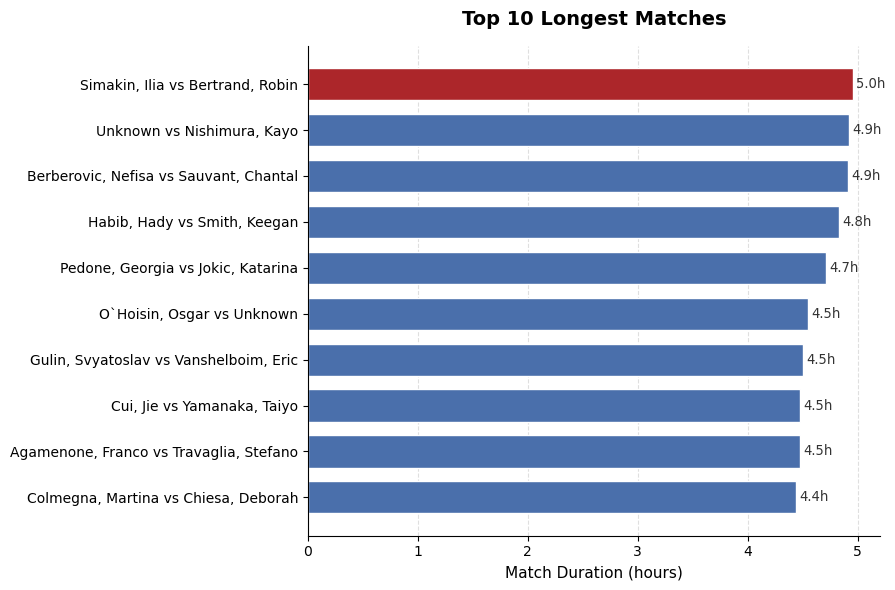

In [7]:
# Visualization: top 10 longest matches after cleaning
top10 = candidates.sort_values('duration_seconds', ascending=False).head(10).merge(
    pd.concat([
        home[['match_id', 'full_name']].rename(columns={'full_name': 'home_name'}),
    ]), on='match_id', how='left').merge(
    away[['match_id', 'full_name']].rename(columns={'full_name': 'away_name'}), on='match_id', how='left')
top10['label'] = top10['home_name'] + ' vs ' + top10['away_name']
top10['hours'] = top10['duration_seconds'] / 3600

top10['home_name'] = top10['home_name'].fillna('Unknown')
top10['away_name'] = top10['away_name'].fillna('Unknown')

top10['label'] = top10['home_name'] + ' vs ' + top10['away_name']
top10['hours'] = top10['duration_seconds'] / 3600
top10 = top10.iloc[::-1]


 
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#4A6FAB"] * 9 + ["#AC262A"]
bars = ax.barh(top10['label'], top10['hours'], color=colors, edgecolor='white', height=0.7)
for bar, hrs in zip(bars, top10['hours']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{hrs:.1f}h', va='center', fontsize=9.5, color='#333333')
ax.set_xlabel('Match Duration (hours)', fontsize=11)
ax.set_title('Top 10 Longest Matches', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('charts\q4_longest_matches.png', dpi=200, bbox_inches='tight')


Observation: Duration was limited to 15–300 minutes, duration_reliable rows, and a seconds-per-game check against recorded scores. Longest match: Simakin vs Bertrand (Monastir, ITF Men, hard outdoor), 4h 57m over 35 games (2024-02-10). Top 10 fall between about 4.4h and 5.0h.

Interpretation: Clustering near 300 minutes partly reflects the upper cutoff: longer values are excluded by design. The result is the longest match inside the plausible window, not proof that nothing real exceeded 5 hours.

Limitation: Pace checks internal consistency only, not an official external record. Genuine matches longer than 300 minutes (e.g. with delays in the clock) would be dropped, not flagged.